# Discount and profit analysis

The EDA showed discount correlating with margin at -0.86. Correlation is not enough to set a
policy on, so this notebook tests it properly:

1. A scatter of discount against margin with a fitted line, to see the shape.
2. An OLS regression controlling for quantity and category, to check the effect survives.
3. ANOVA and Kruskal-Wallis across discount tiers, to confirm the tiers really differ.
4. A per-sub-category break-even discount, to turn the finding into a number ops can act on.

The statistics live in `src/profitability.py` so they can be tested and rerun. This notebook
is the narrative over them.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import plotting as viz
from src.utils import load_analysis_frame

viz.apply_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

from src import profitability as prof

data = prof.prepare()
print(f"{len(data):,} order lines")
data[["sales", "discount", "profit", "margin_pct", "discount_tier"]].head(3)

9,994 order lines


,sales,discount,profit,margin_pct,discount_tier
0,261.96,0.0,41.9136,16.0,0%
1,731.94,0.0,219.5820,30.0,0%
2,14.62,0.0,6.8714,47.0,0%


## The shape of the relationship

Every order line, discount against margin. A 2% sample of points would hide the structure, so
all 9,994 are plotted with heavy transparency, and the tier means are drawn on top.

findfont: Failed to find font weight semibold, now using 700.


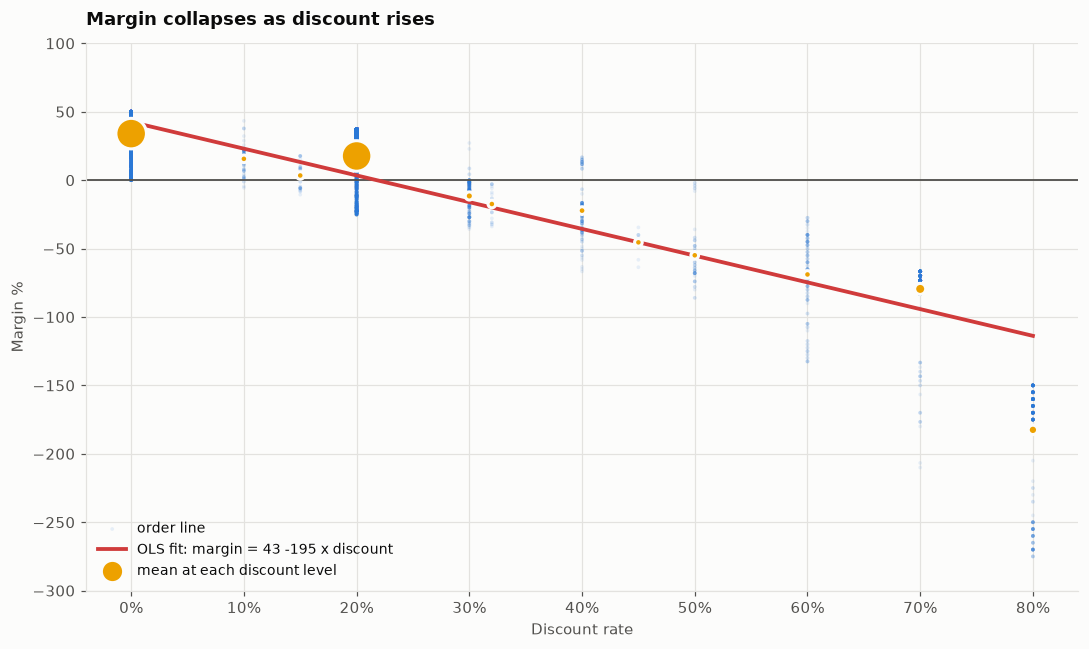

In [2]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(data["discount"], data["margin_pct"], s=6, alpha=0.10,
           color=viz.CATEGORICAL[0], edgecolors="none", label="order line")
ax.axhline(0, color=viz.INK_MUTED, linewidth=1.2)

# Fitted line across the observed range.
fit = np.polyfit(data["discount"], data["margin_pct"], 1)
grid = np.linspace(0, data["discount"].max(), 100)
ax.plot(grid, np.polyval(fit, grid), color=viz.PROFIT_NEGATIVE, linewidth=2.5,
        label=f"OLS fit: margin = {fit[1]:.0f} {fit[0]:+.0f} x discount")

# Mean margin per observed discount level, sized by how many lines sit there.
levels = data.groupby("discount").agg(
    margin=("margin_pct", "mean"), lines=("margin_pct", "size")
).reset_index()
ax.scatter(levels["discount"], levels["margin"],
           s=np.clip(levels["lines"] / 8, 25, 400), color=viz.CATEGORICAL[3],
           edgecolors=viz.SURFACE, linewidths=2, zorder=5, label="mean at each discount level")

ax.set_xlabel("Discount rate")
ax.set_ylabel("Margin %")
ax.set_title("Margin collapses as discount rises")
ax.set_ylim(-300, 100)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(loc="lower left", fontsize=9)

fig.tight_layout()
viz.save_figure(fig, "discount_vs_margin_scatter")
plt.show()

The relationship is close to linear and steeply negative. Two things the scatter shows that a
correlation coefficient does not:

**The data is concentrated in a few vertical stripes.** Discounts are set at 0%, 20%, and a
scattering of higher standard rates, so this is not a finely tuned pricing function. It is a
handful of policies.

**Margin variance widens as discount rises.** At 0% the points cluster tightly around +34%.
Past 40% they fan out over hundreds of percentage points of loss. That is heteroskedasticity,
and it is the reason the regression below uses robust standard errors and the tier test is
reported both parametrically and non-parametrically.

## Regression

Margin is the response rather than dollar profit. Profit in dollars mixes pricing quality with
order size, which is why its raw correlation with discount looked weak (-0.22) while margin's
was strong (-0.86). Both models are fitted so the difference is visible.

In [3]:
margin_model = prof.fit_margin_model(data)
profit_model = prof.fit_profit_model(data)

print(margin_model.summary().tables[0])
print(margin_model.summary().tables[1])

                            OLS Regression Results                            
Dep. Variable:             margin_pct   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.751
Method:                 Least Squares   F-statistic:                     2557.
Date:                Thu, 13 Aug 2026   Prob (F-statistic):               0.00
Time:                        22:26:51   Log-Likelihood:                -45650.
No. Observations:                9994   AIC:                         9.131e+04
Df Residuals:                    9989   BIC:                         9.135e+04
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [4]:
comparison = pd.DataFrame({
    "model": ["margin_pct ~ discount + quantity + category",
              "profit ~ discount + quantity + category"],
    "adj_r_squared": [margin_model.rsquared_adj, profit_model.rsquared_adj],
    "discount_coef": [margin_model.params["discount"], profit_model.params["discount"]],
    "discount_p": [margin_model.pvalues["discount"], profit_model.pvalues["discount"]],
})
comparison.round(4)

,model,adj_r_squared,discount_coef,discount_p
0,margin_pct ~ discount + quantity + category,0.7505,-195.170,0.0
1,profit ~ discount + quantity + category,0.0608,-243.612,0.0


**Discount explains 75.1% of the variance in margin.** For a single behavioural driver in real
commercial data that is an unusually clean result, and it is the empirical core of the whole
project.

The coefficient is **-195.2**: every additional 10 points of discount costs **19.5 points of
margin**, holding quantity and category constant. Since the average margin at full price is
about 34 points, roughly 17 points of discount is enough to wipe out the entire margin on an
average line.

Quantity contributes almost nothing, which matches the weak 0.20 correlation between sales and
quantity found in the EDA. Volume is not buying anything here.

The same specification against dollar profit gives **-$24.36 of profit per 10 points of
discount** and an adjusted R-squared of just 0.061. Same relationship, far noisier response
variable. This is why the margin model is the one to quote.

## Do the discount tiers actually differ?

Binning into the tiers from the plan and testing whether margin genuinely differs across them.

In [5]:
tiers = prof.tier_summary(data)
tests = prof.test_discount_tiers(data)

print(f"ANOVA            F = {tests.anova_f:,.1f}   p = {tests.anova_p:.3e}")
print(f"Kruskal-Wallis   H = {tests.kruskal_h:,.1f}   p = {tests.kruskal_p:.3e}")
print(f"Levene equal-variance p = {tests.levene_p:.3e} "
      f"({'holds' if tests.variances_are_equal else 'violated'})")
tiers.round(2)

ANOVA            F = 5,590.1   p = 0.000e+00
Kruskal-Wallis   H = 4,672.2   p = 0.000e+00
Levene equal-variance p = 0.000e+00 (violated)


,discount_tier,order_lines,sales,profit,mean_margin_pct,median_margin_pct,pct_loss_making
0,0%,4798,1087908.47,320987.60,34.02,34.00,0.00
1,1-10%,94,54369.35,9029.18,15.58,16.67,4.26
2,11-20%,3709,792152.89,91756.30,17.48,16.25,13.99
3,21-30%,227,103226.66,-10369.28,-11.55,-8.57,91.63
4,30%+,1166,259543.49,-125006.78,-91.47,-73.33,97.77


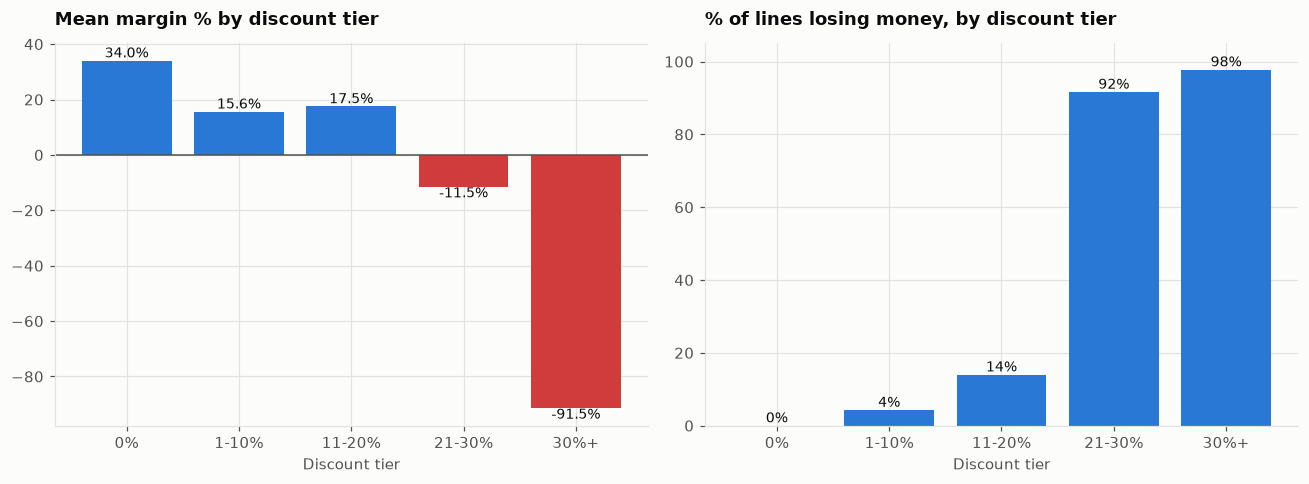

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(tiers["discount_tier"].astype(str), tiers["mean_margin_pct"],
            color=viz.profit_colors(tiers["mean_margin_pct"]))
axes[0].axhline(0, color=viz.INK_MUTED, linewidth=1)
axes[0].set_title("Mean margin % by discount tier")
for x, v in enumerate(tiers["mean_margin_pct"]):
    axes[0].annotate(f"{v:,.1f}%", (x, v), ha="center",
                     va="bottom" if v >= 0 else "top", fontsize=9, color=viz.INK)

axes[1].bar(tiers["discount_tier"].astype(str), tiers["pct_loss_making"],
            color=viz.CATEGORICAL[0])
axes[1].set_title("% of lines losing money, by discount tier")
axes[1].set_ylim(0, 105)
for x, v in enumerate(tiers["pct_loss_making"]):
    axes[1].annotate(f"{v:,.0f}%", (x, v), ha="center", va="bottom", fontsize=9, color=viz.INK)

for ax in axes:
    ax.set_xlabel("Discount tier")

fig.tight_layout()
viz.save_figure(fig, "margin_by_discount_tier")
plt.show()

Both tests reject the null overwhelmingly: **ANOVA F = 5,590.1** and **Kruskal-Wallis
H = 4,672.2**, each at p below any threshold worth naming.

Reporting both is deliberate. Levene's test rejects equal variances, which violates an ANOVA
assumption, so the parametric result on its own would be open to challenge. Kruskal-Wallis
assumes nothing about the distribution and agrees, so the conclusion does not depend on the
broken assumption.

The tier means locate the cliff exactly: **+17.5% at 11-20%, then -11.6% at 21-30%**. The
share of loss-making lines goes from 14% to 92% across the same step. There is no gentle
decline between them.

One honest caveat: the 1-10% tier holds only 94 lines, so its 15.6% mean is thin evidence and
sits slightly below the 11-20% tier, which is almost certainly noise rather than signal.

## Where does each sub-category break even?

A regression of margin on discount within each sub-category, solved for where fitted margin
crosses zero. That crossing is the discount ceiling implied by the line's own trading history.

In [7]:
breakeven = prof.breakeven_by_sub_category(data)
breakeven[["sub_category", "category", "order_lines", "avg_discount",
           "breakeven_discount", "headroom", "margin_pct", "note"]].round(4)

,sub_category,category,order_lines,avg_discount,breakeven_discount,headroom,margin_pct,note
1,Appliances,Office Supplies,466,0.1665,0.1215,-0.0450,16.8675,within observed range
4,Bookcases,Furniture,228,0.2111,0.1540,-0.0571,-3.0228,within observed range
14,Storage,Office Supplies,846,0.0747,0.1555,0.0808,9.5061,within observed range
16,Tables,Furniture,319,0.2613,0.1639,-0.0974,-8.5645,within observed range
15,Supplies,Office Supplies,190,0.0768,0.1681,0.0912,-2.5477,within observed range
5,Chairs,Furniture,617,0.1702,0.2085,0.0383,8.0957,within observed range
9,Furnishings,Furniture,957,0.1383,0.2225,0.0842,14.2404,within observed range
13,Phones,Technology,889,0.1546,0.2667,0.1121,13.4893,within observed range
11,Machines,Technology,115,0.3061,0.2699,-0.0362,1.7886,within observed range
3,Binders,Office Supplies,1523,0.3723,0.2879,-0.0844,14.8574,within observed range


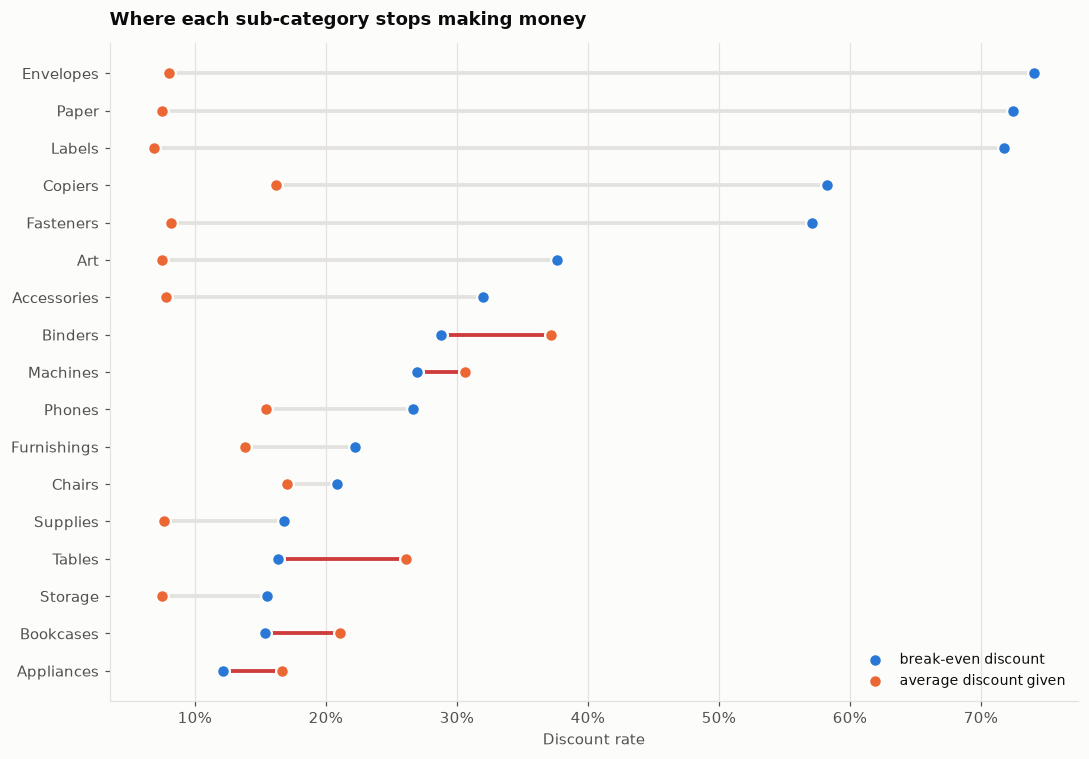

In [8]:
plot_data = breakeven.dropna(subset=["breakeven_discount"]).sort_values("breakeven_discount")
y = np.arange(len(plot_data))

fig, ax = plt.subplots(figsize=(10, 7))

# A line from what is charged to where the line breaks even. Red where the gap is a deficit.
for i, row in enumerate(plot_data.itertuples()):
    over = row.avg_discount > row.breakeven_discount
    ax.plot([row.avg_discount, row.breakeven_discount], [i, i],
            color=viz.PROFIT_NEGATIVE if over else viz.GRID, linewidth=2.5, zorder=1)

ax.scatter(plot_data["breakeven_discount"], y, s=70, color=viz.CATEGORICAL[0], zorder=3,
           edgecolors=viz.SURFACE, linewidths=1.5, label="break-even discount")
ax.scatter(plot_data["avg_discount"], y, s=70, color=viz.CATEGORICAL[1], zorder=3,
           edgecolors=viz.SURFACE, linewidths=1.5, label="average discount given")

ax.set_yticks(y, plot_data["sub_category"])
ax.set_xlabel("Discount rate")
ax.set_title("Where each sub-category stops making money")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", visible=False)

fig.tight_layout()
viz.save_figure(fig, "breakeven_discount_by_sub_category")
plt.show()

Red segments are sub-categories sold past their own break-even point. There are five:

| Sub-category | Breaks even at | Actually sold at | Past the ceiling by |
| --- | ---: | ---: | ---: |
| Tables | 16.4% | 26.1% | 9.7 points |
| Binders | 28.8% | 37.2% | 8.4 points |
| Bookcases | 15.4% | 21.1% | 5.7 points |
| Appliances | 12.2% | 16.7% | 4.5 points |
| Machines | 27.0% | 30.6% | 3.6 points |

**Tables is the clearest case.** It breaks even at a 16.4% discount, is sold at 26.1% on
average, and returns a -8.6% margin across 319 lines. The fit is good (R-squared 0.86), so
this is not an artefact of a noisy regression.

**Binders is the largest by volume.** 1,523 lines, an average discount of 37.2% against a
28.8% break-even. It still shows a positive 14.9% margin overall because its full-price sales
are highly profitable, which means the damage is hidden inside the average rather than absent.
That is the case for a per-line cap rather than a category-level judgement.

At the other end, Paper, Labels, and Envelopes break even only past 70% discount and are never
discounted beyond 20%. They have room to be used for promotion, if promotion is needed.

## Conclusion

The central business question has a direct answer.

**Discounting above roughly 20% destroys margin, and it explains three quarters of the
variation in margin across the business.** The relationship is linear, steep, statistically
overwhelming under both parametric and non-parametric tests, and consistent across every level
of the analysis: order lines, discount tiers, sub-categories, and customers.

The actionable form of it is the five sub-categories above, where the discount routinely given
already exceeds the point at which the line stops paying for itself. Capping those five at
their break-even rate is the single highest-value change available in this dataset.